<img src="https://github.com/IOAI-official/IOAI-2025/blob/main/Individual-Contest/Antique/figs/IOAI-Logo.png?raw=1" alt="IOAI Logo" width="200" height="auto">

[IOAI 2025 (Beijing, China), Individual Contest](https://ioai-official.org/china-2025)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1OWWxO7RG7EtzgrTIDyYgG0nkedK6AjbG?usp=sharing)

### Train Your Model

In [ ]:
import os
import sys

# 1. Get the current working directory
current_dir = os.getcwd()

# 2. Check if the path contains "Individual-Contest/Antique" and trim it to that point
if "Individual-Contest/Antique" in current_dir:
    root_index = current_dir.index("Individual-Contest/Antique") + len("Individual-Contest/Antique")
    project_root = current_dir[:root_index]
else:
    raise Exception("Project root directory not found. Please check the folder structure.")

# 3. Change working directory to the project root
os.chdir(project_root)
print("Working directory set to:", os.getcwd())

# 4. Add module search path (e.g., where metrics.py is located)
sys.path.append(os.path.join(project_root, "Scoring"))

Exception: Project root directory not found. Please check the folder structure.

<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_752/225164212.py:66: SyntaxWarning: invalid escape sequence '\m'
  plt.suptitle("Pairwise Digital Feature Distributions ($\mathbf{C}_2^5 = 10$ Combinations)", y=1.07, fontsize=16, fontweight='bold')


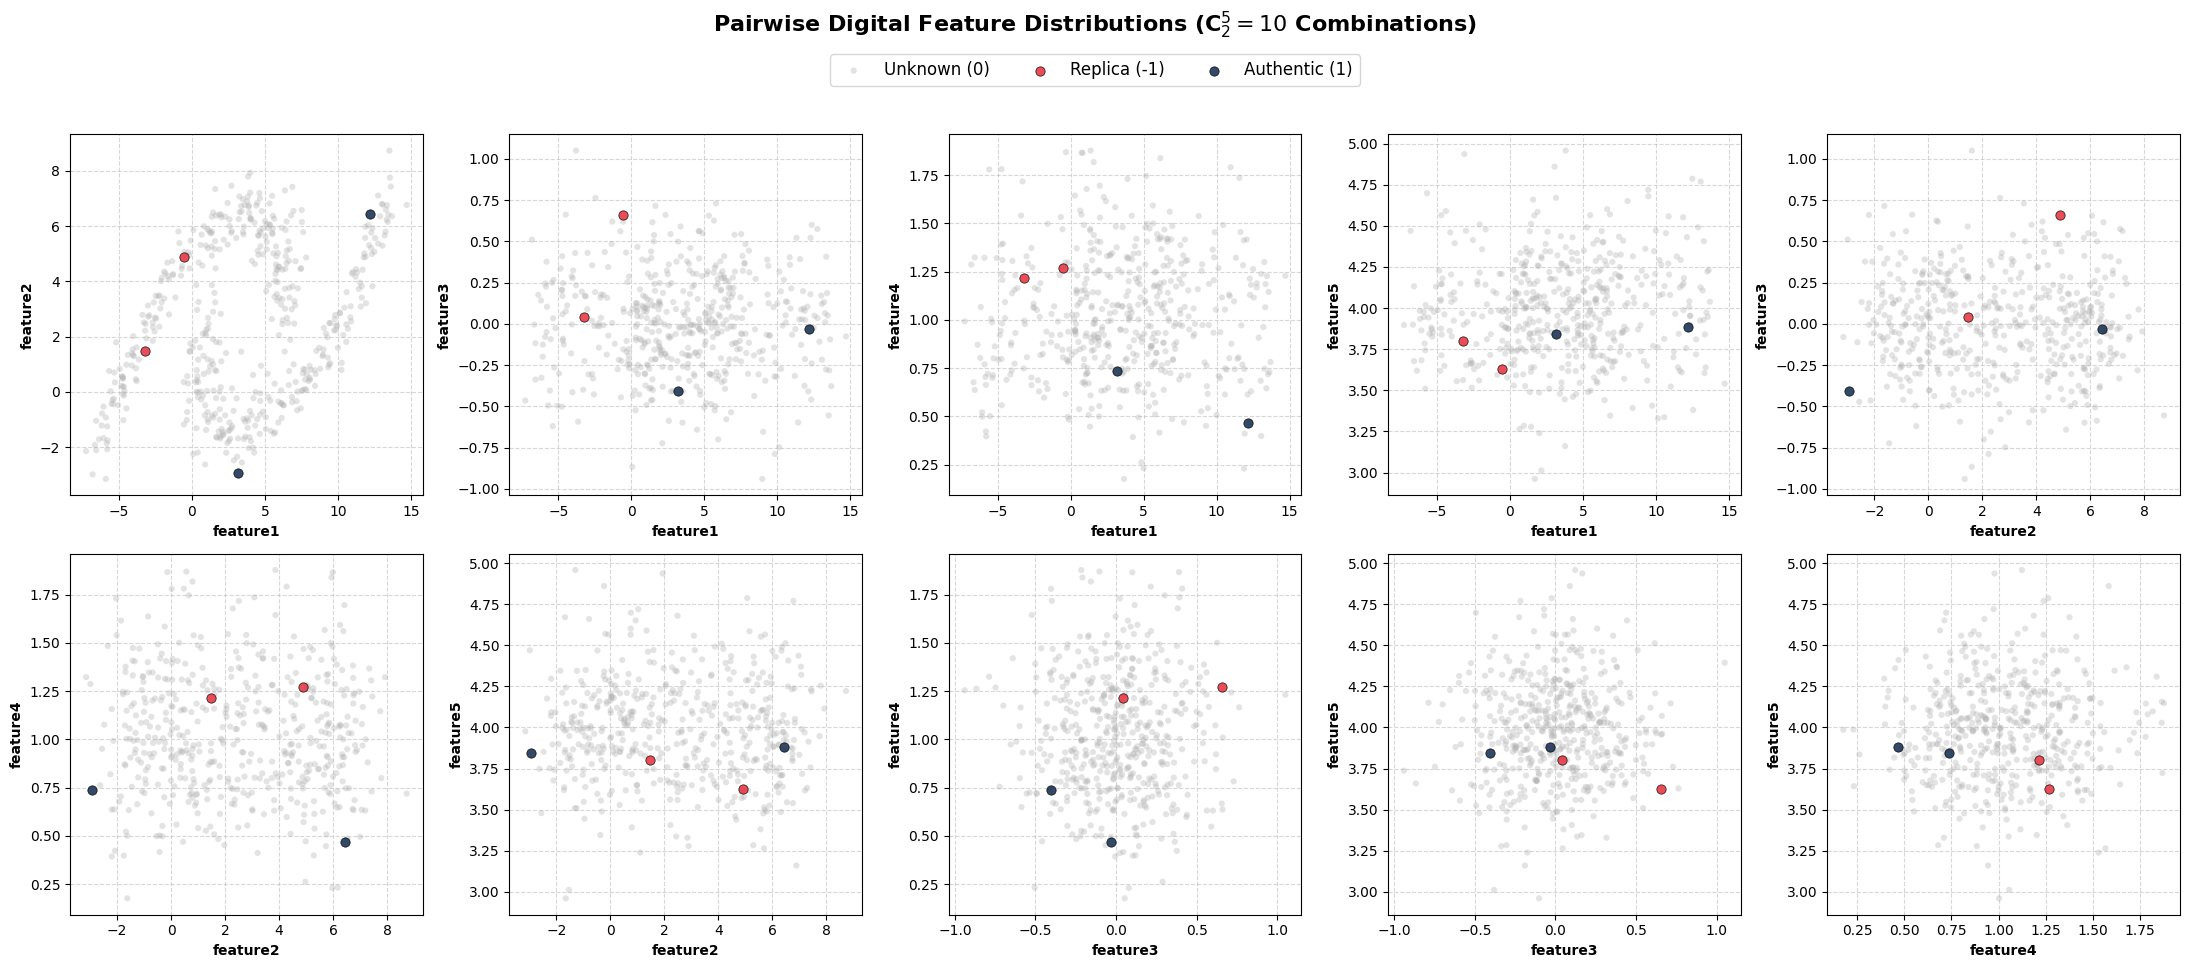

In [ ]:
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. Load Data
# -------------------------------------------------------------
TRAIN_PATH = "./training_set/"
train = pd.read_csv(TRAIN_PATH + "training_set.csv")

feature_cols = list(train.columns[:5])
label_col = train.columns[5]

# -------------------------------------------------------------
# 2. Setup Combinations & Styling
# -------------------------------------------------------------
# Generate all 5C2 = 10 combinations of features
combinations_2d = list(itertools.combinations(feature_cols, 2))

# Color and style specifications
color_map = {
    0:  {'color': '#B0B0B0', 'label': 'Unknown (0)',    'alpha': 0.35, 's': 20, 'zorder': 1},
    -1: {'color': '#E63946', 'label': 'Replica (-1)',   'alpha': 0.90, 's': 45, 'zorder': 2},
    1:  {'color': '#1D3557', 'label': 'Authentic (1)',  'alpha': 0.90, 's': 45, 'zorder': 3}
}

# -------------------------------------------------------------
# 3. Create Multi-Panel Plot
# -------------------------------------------------------------
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(22, 9))
axes = axes.flatten()

for idx, (f_x, f_y) in enumerate(combinations_2d):
    ax = axes[idx]

    # Plot classes in order: 0 (gray), -1 (red), 1 (blue)
    for class_val in [0, -1, 1]:
        subset = train[train[label_col] == class_val]
        cfg = color_map[class_val]
        ax.scatter(
            subset[f_x],
            subset[f_y],
            c=cfg['color'],
            label=cfg['label'] if idx == 0 else "",
            alpha=cfg['alpha'],
            s=cfg['s'],
            zorder=cfg['zorder'],
            edgecolors='none' if class_val == 0 else 'black',
            linewidths=0.5
        )

    ax.set_xlabel(f_x, fontsize=10, fontweight='bold')
    ax.set_ylabel(f_y, fontsize=10, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)

# Add single unified legend for all subplots
fig.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.03),
    ncol=3,
    fontsize=12,
    frameon=True
)

plt.suptitle("Pairwise Digital Feature Distributions ($\mathbf{C}_2^5 = 10$ Combinations)", y=1.07, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_752/1141081638.py:53: SyntaxWarning: invalid escape sequence '\m'
  plt.suptitle("3D Feature Combinations ($\mathbf{C}_3^5 = 10$ Subplots)", y=1.05, fontsize=16, fontweight='bold')


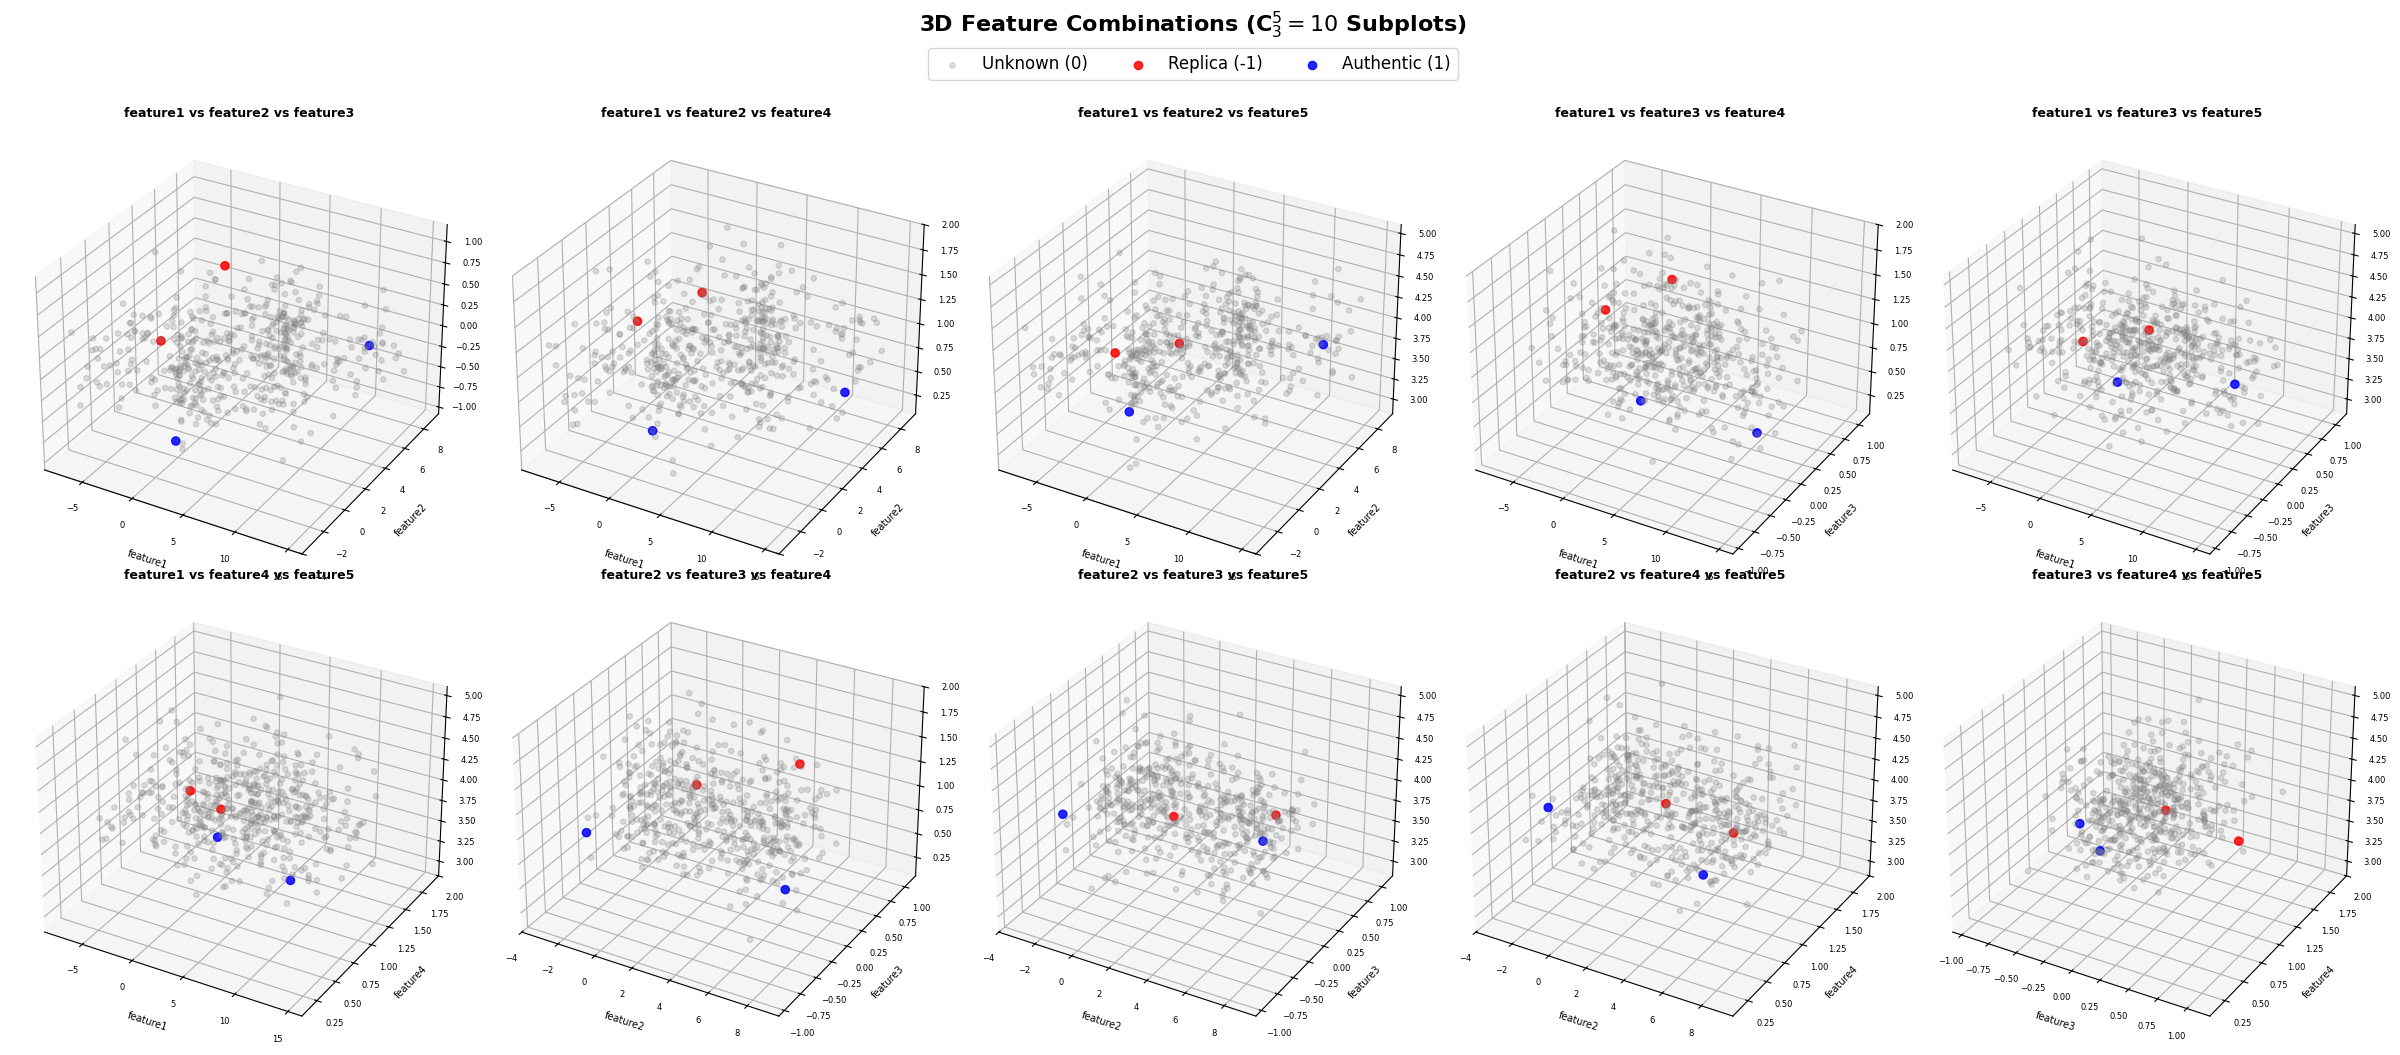

In [ ]:
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. Load Data
# -------------------------------------------------------------
TRAIN_PATH = "./training_set/"
train = pd.read_csv(TRAIN_PATH + "training_set.csv")

feature_cols = list(train.columns[:5])
label_col = train.columns[5]

# Generate all 5C3 = 10 combinations
combinations_3d = list(itertools.combinations(feature_cols, 3))

# Color mapping
color_map = {
    0:  {'color': 'gray', 'label': 'Unknown (0)',   'alpha': 0.25, 's': 15},
    -1: {'color': 'red',  'label': 'Replica (-1)',  'alpha': 0.85, 's': 35},
    1:  {'color': 'blue', 'label': 'Authentic (1)', 'alpha': 0.85, 's': 35}
}

# -------------------------------------------------------------
# 2. Render 3D Subplots
# -------------------------------------------------------------
fig = plt.figure(figsize=(24, 10))

for idx, (f_x, f_y, f_z) in enumerate(combinations_3d):
    ax = fig.add_subplot(2, 5, idx + 1, projection='3d')

    for class_val in [0, -1, 1]:
        subset = train[train[label_col] == class_val]
        cfg = color_map[class_val]
        ax.scatter(
            subset[f_x],
            subset[f_y],
            subset[f_z],
            c=cfg['color'],
            alpha=cfg['alpha'],
            s=cfg['s'],
            label=cfg['label'] if idx == 0 else ""
        )

    ax.set_title(f"{f_x} vs {f_y} vs {f_z}", fontsize=9, fontweight='bold')
    ax.set_xlabel(f_x, fontsize=7)
    ax.set_ylabel(f_y, fontsize=7)
    ax.set_zlabel(f_z, fontsize=7)
    ax.tick_params(labelsize=6)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=12)
plt.suptitle("3D Feature Combinations ($\mathbf{C}_3^5 = 10$ Subplots)", y=1.05, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [31]:
import pandas as pd
import numpy as np
import os
from sklearn.svm import SVC
from sklearn.semi_supervised import LabelSpreading

TRAIN_PATH = "./training_set/"
train = pd.read_csv(TRAIN_PATH + "training_set.csv")

X = np.array(train.iloc[:,:5])
y = np.array(train.iloc[:,5])

# Original: 1 (authentic), -1 (replica), 0 (unlabeled)
# Required: 1 (authentic), 0 (replica), -1 (unlabeled)
y_ls = y.copy()
y_ls[y == -1] = 0
y_ls[y == 0] = -1

label_prop_model = LabelSpreading(kernel='rbf', gamma=10, max_iter=50)
label_prop_model.fit(X, y_ls)

pseudo_labels_ls = label_prop_model.transduction_

pseudo_labels = pseudo_labels_ls.copy()
pseudo_labels[pseudo_labels_ls == 0] = -1

svm_binary_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_binary_model.fit(X, pseudo_labels)


SVC(random_state=42)

### Make Predictions on the Validation and Test Set

In [27]:
VAL_DATA_PATH = "./Solution/validation_set/"
TEST_DATA_PATH = "./Solution/test_set/"

testA = np.array(pd.read_csv(VAL_DATA_PATH + "validation_set.csv"))
testB = np.array(pd.read_csv(TEST_DATA_PATH + "test_set.csv"))

predA = svm_binary_model.predict(testA)
predB = svm_binary_model.predict(testB)

### Generate `submission.zip` for Submission

In [28]:
import zipfile
import os

submissionA = pd.DataFrame(predA)
submissionA.to_csv("./Scoring/submissionA.csv", index=False, header=False)

submissionB = pd.DataFrame(predB)
submissionB.to_csv("./Scoring/submissionB.csv", index=False, header=False)

files_to_zip = ['./Scoring/submissionA.csv', './Scoring/submissionB.csv']
zip_filename = './Scoring/submission.zip'

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        zipf.write(file, os.path.basename(file))

print(f'{zip_filename} is created succefully!')

./Scoring/submission.zip is created succefully!


### Evaluate the Model Performance

In [29]:
%run Scoring/metrics.py

Accuracy for test A: 0.90
Accuracy for test B: 0.90


<Figure size 640x480 with 0 Axes>